## 1. plot generative structure wyckoff distribution

In [ ]:
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.pyplot as plt

plt.style.use(["science", "ieee", "no-latex"])


def process_data(ser):
    return list(ser['nwys']), list(ser['counter'])

In [ ]:
def plot(ser_mp20, ser_50k, ser_230k):
    x1, y1 = process_data(ser_mp20)
    x2, y2 = process_data(ser_50k)
    x3, y3 = process_data(ser_230k)
    
    plt.figure(figsize=(10, 4))
    plt.bar([x1[i]-0.2 for i in range(len(x1))], y1, color = 'blue',width=0.2,label='mp20') 
    plt.bar([x2[i] for i in range(len(x2))], y2, color = 'red', width=0.2, label='50k') 
    plt.bar([x3[i]+0.2 for i in range(len(x3))], y3, color = 'green', width=0.2, label='230k') 
    plt.legend()
    #plt.savefig("numIons dif of train_v2")
    plt.xticks(x1[::1])
    plt.show()
    
    plt.tight_layout()
    plt.legend()
    plt.savefig("nsites_dis.png", dpi=300)

In [ ]:
mp20_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/analysis/nwys_dis.csv"
V5_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20_aug_V5-adam-BS512-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/20000/analysis/nwys_dis.csv"
dV1_path = "/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS512-LR0.0001-WD0-clip1-A119-W28-N21-LW2-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/10000/analysis/nwys_dis.csv"

mp20 = pd.read_csv(mp20_path)
V5 = pd.read_csv(V5_path)
dV1 = pd.read_csv(dV1_path)

In [ ]:
plot(mp20, V5, dV1)

## 2.plot train set wyckoff distribution

In [ ]:
dV1_t_path = "/public/home/wangqingchang/CrystalFormer/data/aug_debug1/train.csv"
mp20_path = "/public/home/wangqingchang/CrystalFormer/data/mp_20/mp.csv"

In [ ]:
import pandas as pd
mp20 = pd.read_csv(mp20_path)
mp20_train = mp20[:27136]
dV1 = pd.read_csv(dV1_t_path)

In [ ]:
def plot_bar_2var(ser1, ser2):
    
    x1 = ser1.value_counts().index
    y1 = ser1.value_counts().values
    x2 = ser2.value_counts().index
    y2 = ser2.value_counts().values
    plt.figure(figsize=(16, 3)) #adjust according to needs
    w = 0.4
    plt.bar([x1[i]-w/2 for i in range(len(x1))], y1, color = 'blue',width=w,label='mp20') 
    plt.bar([x2[i]+w/2 for i in range(len(x2))], y2, color = 'red', width=w, label='230k') 

    plt.xticks(list(range(0,231,10))) #adjust according to needs
    plt.xlim(0, 230) #adjust according to needs
    plt.tight_layout()
    plt.legend()

In [ ]:
plot_bar_2var(mp20_train['spg'], dV1['spg'])

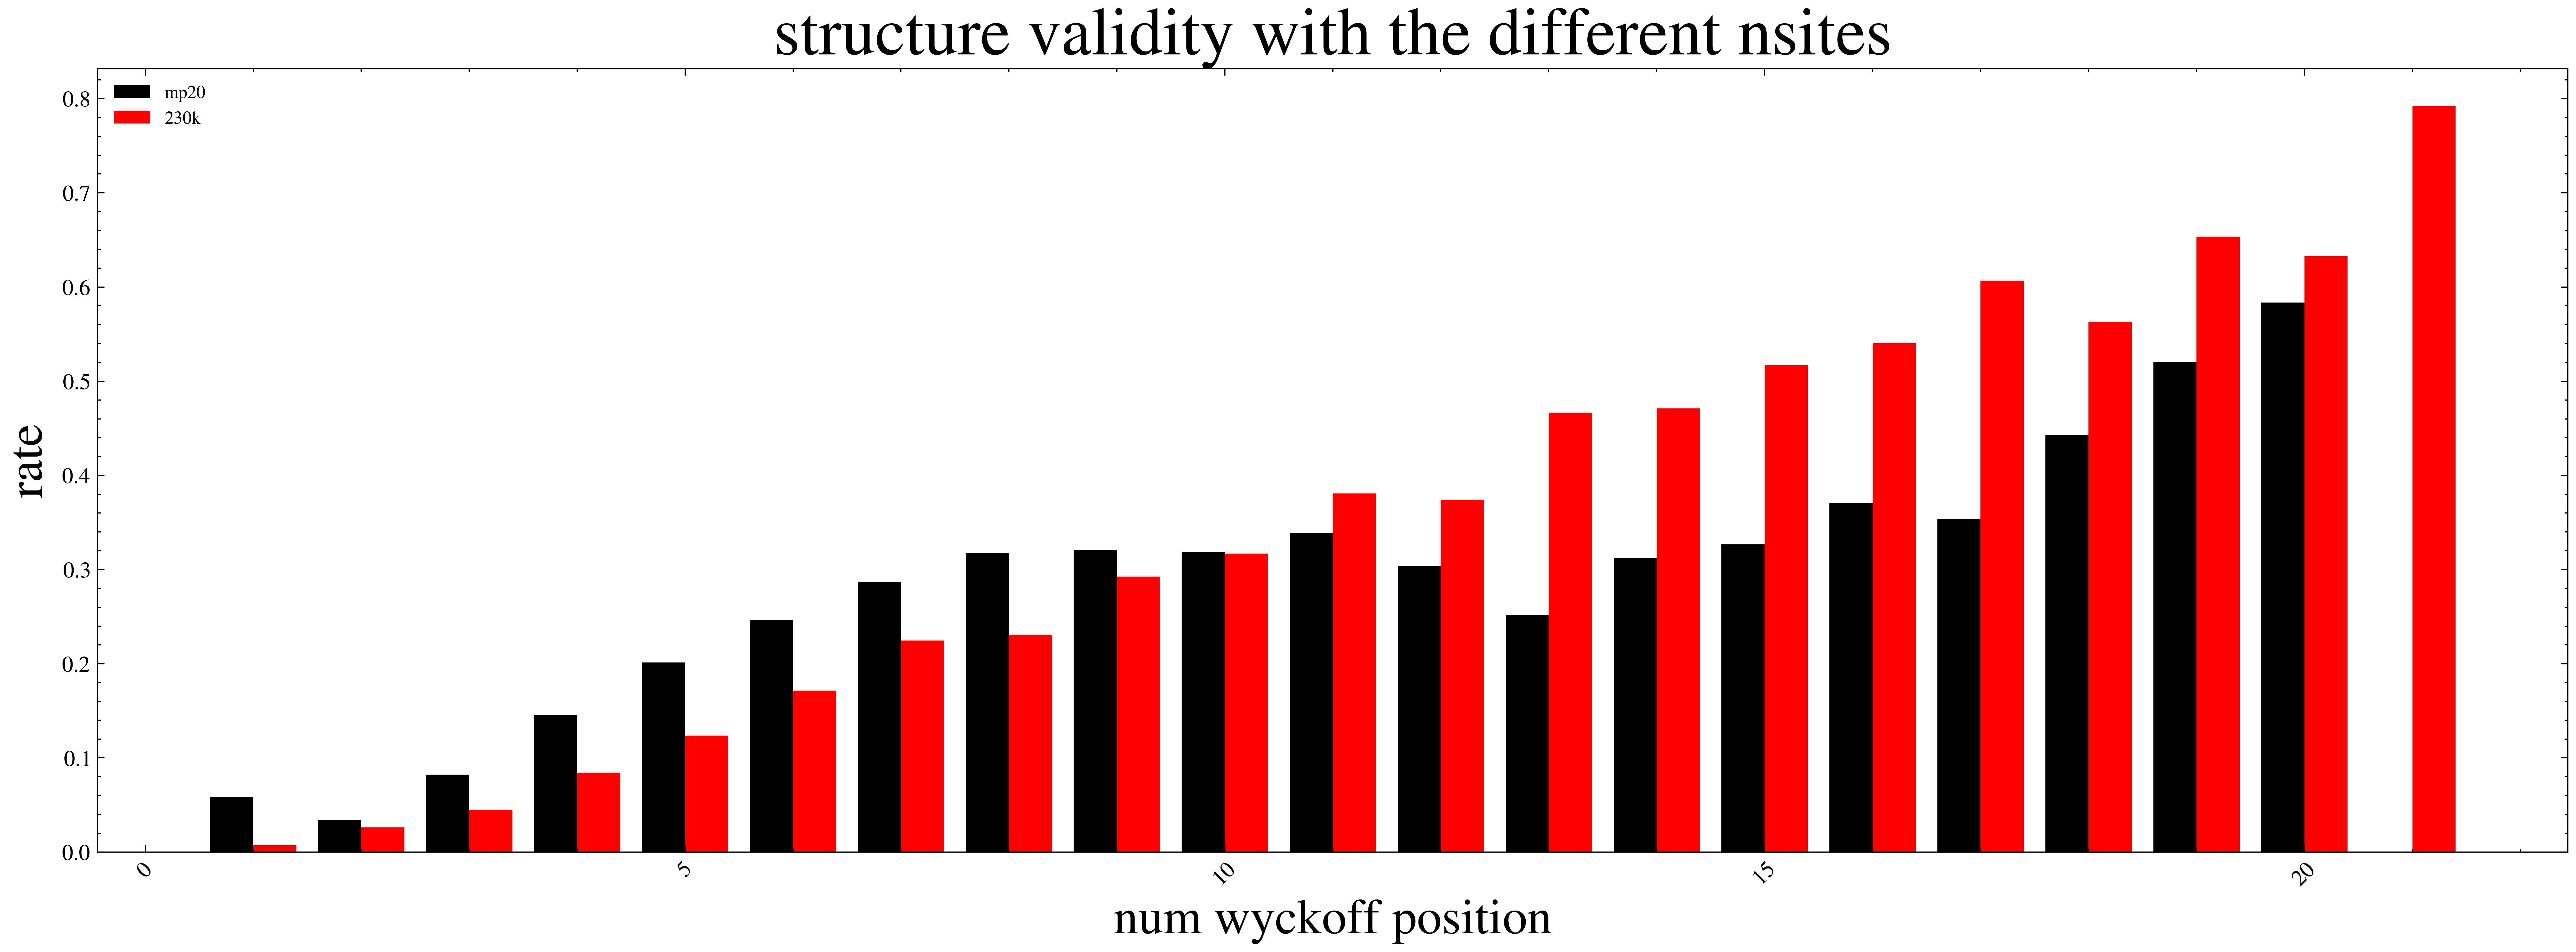

In [ ]:
from utils import plot
import pandas as pd
#fw false wyckoff
#aw all wyckoff

aw_mp20_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/analysis/nwys_dis.csv"
aw_dV1_path = "/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/analysis/nwys_dis.csv"
fw_dV1_path = "/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/false_nwys_dis.csv"
fw_mp20_path = "/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/again/false_nwys_dis.csv"
df_fw_dV1 = pd.read_csv(fw_dV1_path)
df_fw_mp20 = pd.read_csv(fw_mp20_path)
df_aw_dV1 = pd.read_csv(aw_dV1_path)
df_aw_mp20 = pd.read_csv(aw_mp20_path)


fw_V1_key = df_fw_dV1['nwys']
fw_V1_value = df_fw_dV1['counter']/df_aw_dV1['counter']
fw_mp20_key = df_fw_mp20['nwys']
fw_mp20_value = df_fw_mp20['counter']/df_aw_mp20['counter']
plot(((fw_mp20_key, fw_mp20_value, 'mp20'),(fw_V1_key,fw_V1_value,'230k')),xlabel='num wyckoff position', ylabel='rate',title='structure validity with the different nsites')

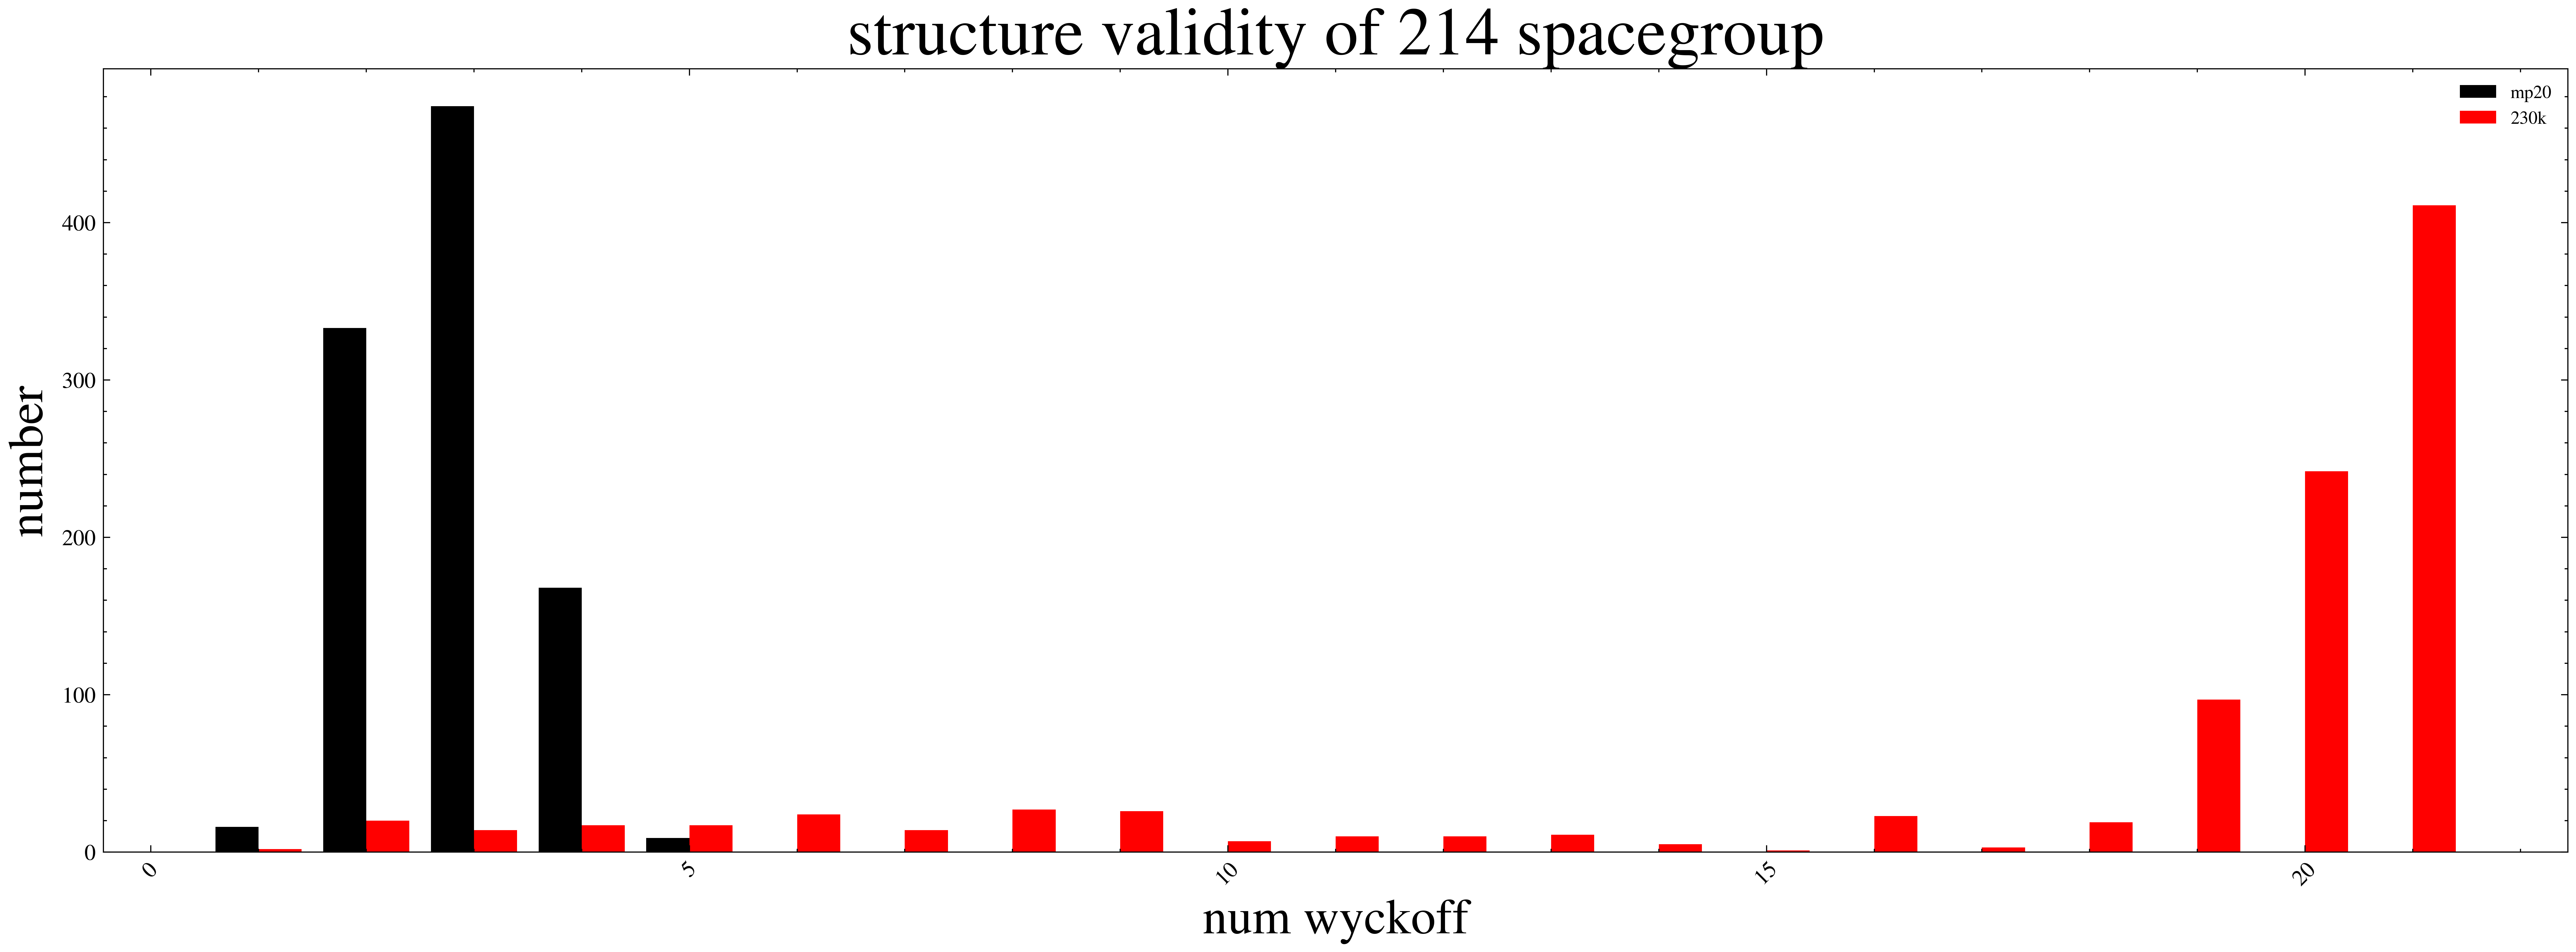

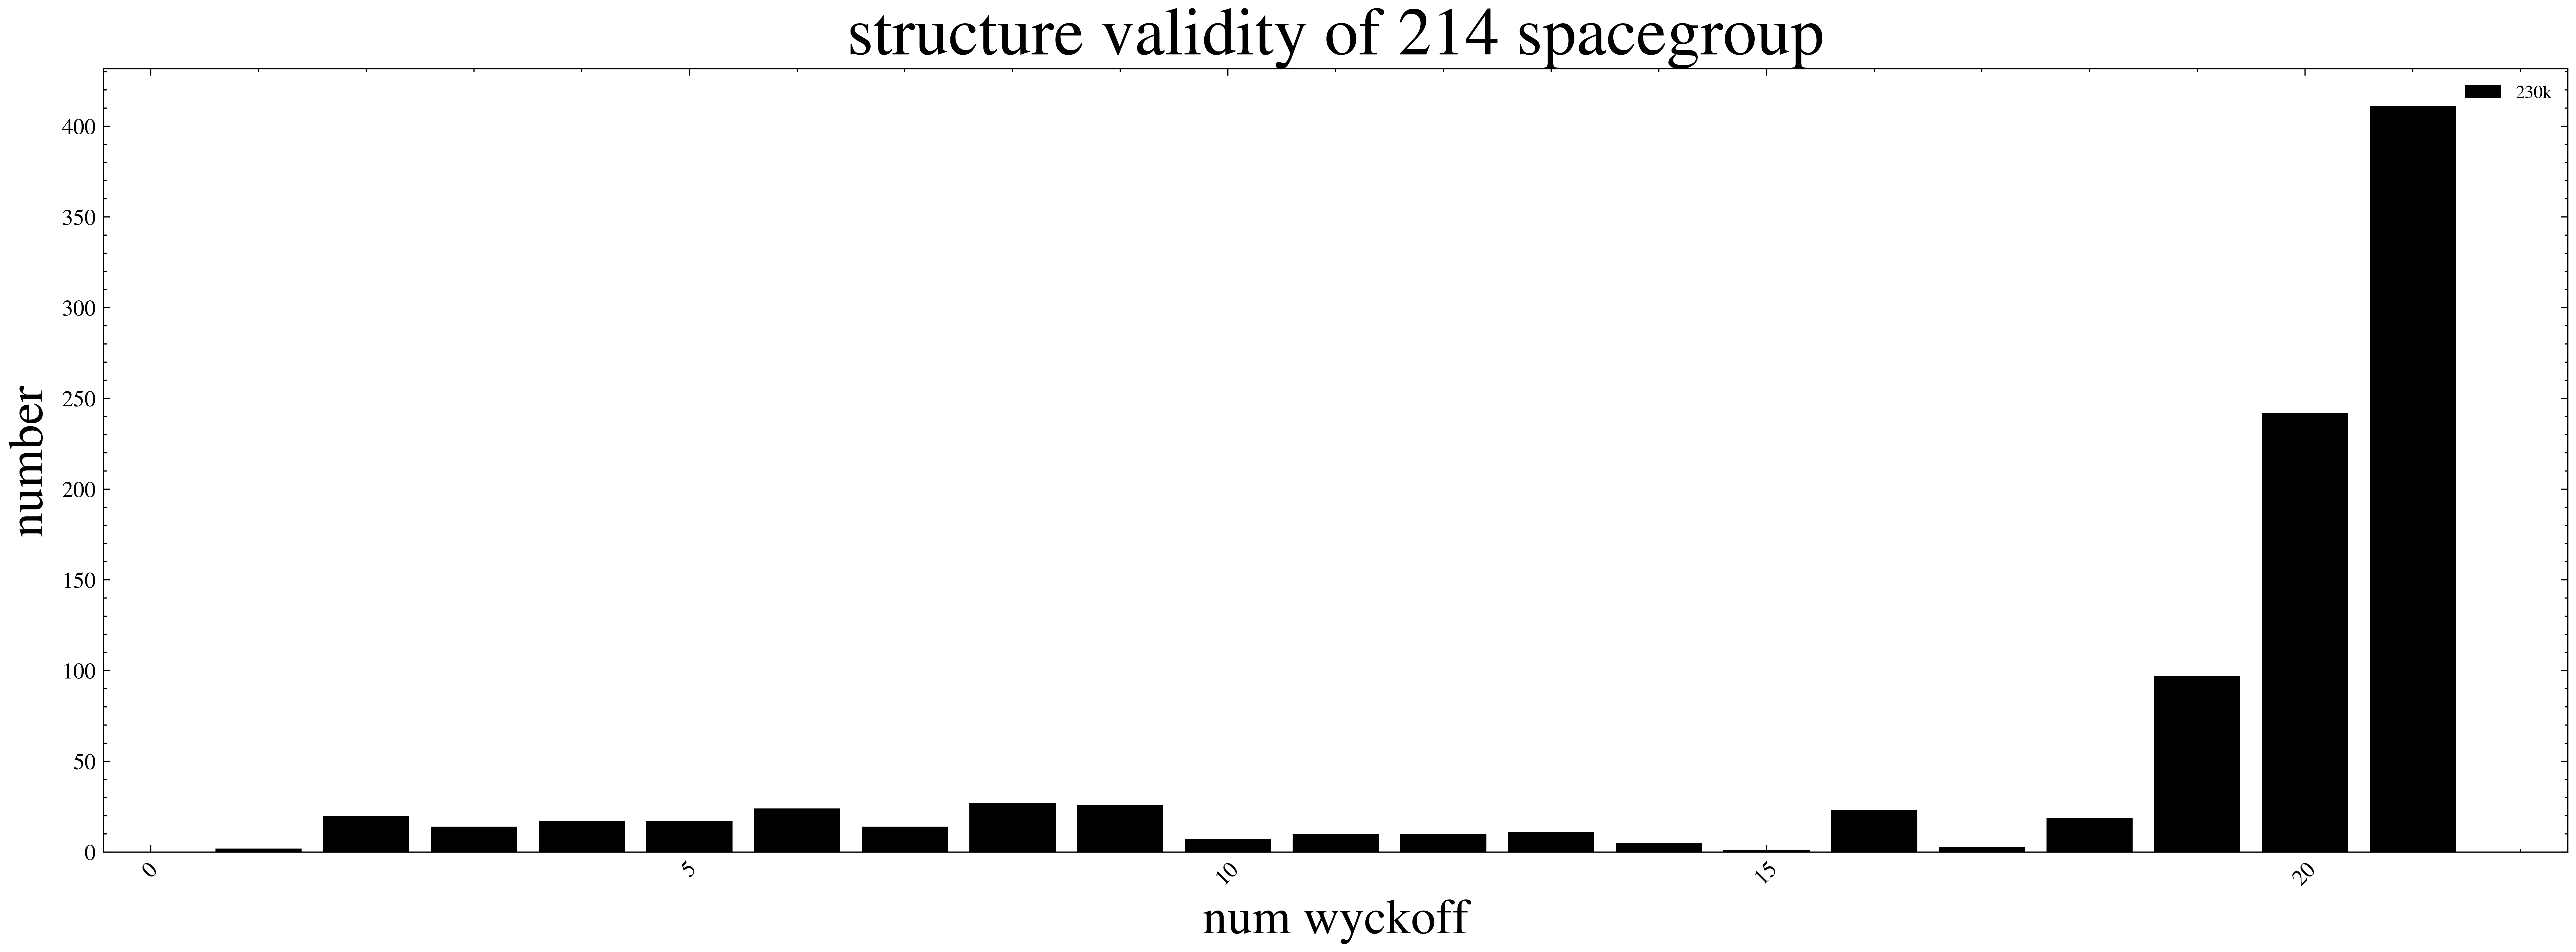

In [3]:
from utils import plot
import pandas as pd
df_214_dV1 = pd.read_csv("/public/home/wangqingchang/CrystalFormer/output/DSaug_debug1-adam-BS128-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.3/9900/214/nwys_dis.csv")
df_214_mp20 = pd.read_csv("/public/home/wangqingchang/CrystalFormer/output/DSmp_20-adam-BS100-LR0.0001-WD0-clip1-A119-W28-N21-LW1-Nf5-Kx16-Kl4-h0256-Tl16-H16-Ks64-Ms64-Es32-drop0.5/5200/again/214/nwys_dis.csv")
k_dv1 = df_214_dV1['nwys']
v_dv1 =  df_214_dV1['counter']
k_mp20 = df_214_mp20['nwys']
v_mp20 = df_214_mp20['counter']
plot(((k_mp20 ,v_mp20 , 'mp20'), (k_dv1 ,v_dv1 , '230k')),xlabel='num wyckoff', ylabel='number',title='structure validity of 214 spacegroup', ax_in_width="30%", ax_in_height="20%")
plot(((k_dv1 ,v_dv1 , '230k'),),xlabel='num wyckoff', ylabel='number',title='structure validity of 214 spacegroup', ax_in_width="30%", ax_in_height="20%")

## test

In [ ]:
import pandas as pd
df = pd.read_csv("/public/home/wangqingchang/CrystalFormer/data/aug_debug1/train.csv")
def _get_nwys(ser):
    for i in range(20):
        wp_i = int(ser[f'wp{i}'])
        if i != 19:
            wp_i_add_1 = int(ser[f'wp{i+1}'])
            if wp_i != -1 and wp_i_add_1 == -1:
                nwys = i+1
                return nwys
        else:
            if wp_i != -1:
                nwys = i+1
            else:
                nwys = i
            return nwys
def get_nwys_from_df(df):
    nwyss = []
    for i in range(len(df)):
        nwys = _get_nwys(df.iloc[i])
        nwyss.append(nwys)
    return nwyss


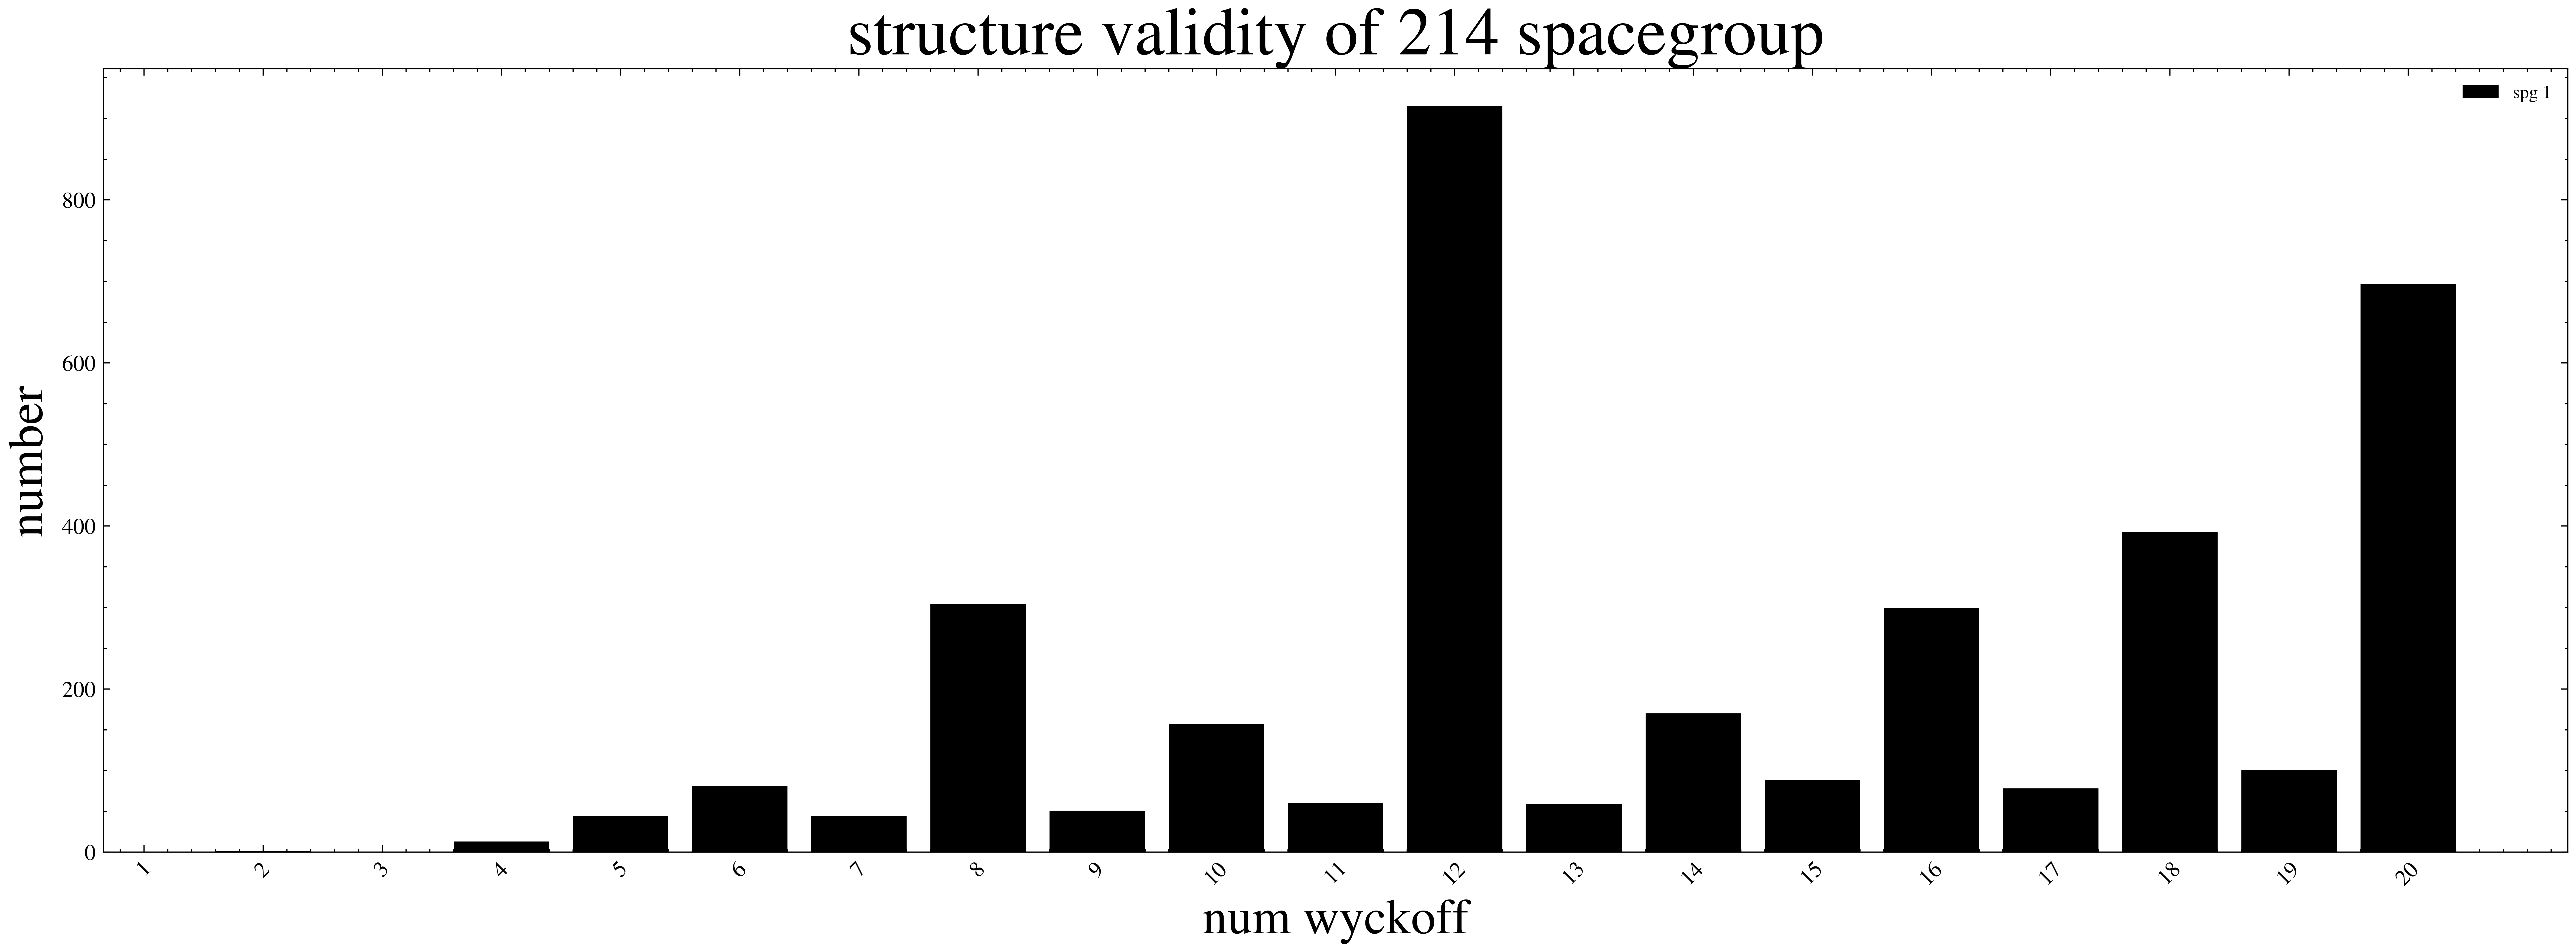

In [33]:
from collections import Counter
from utils import plot
i = 1
a = Counter(get_nwys_from_df(df[df['spg']==i]))
key, value = zip(*sorted(a.items()))
plot(((key ,value , f'spg {i}'),),xlabel='num wyckoff', ylabel='number',title='structure validity of 214 spacegroup', ax_in_width="30%", ax_in_height="20%",xticks=range(1, 21))